# Paper figures
Regenerates every results figure for the paper and writes a PDF into `figures/`.
Run top-to-bottom with the `nn4opt` kernel. Edit the `configs` lists to add/remove
experiments. See `RESULTS_LAYOUT.md` for where each input lives.

In [1]:
import sys, pathlib, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd().parent  # repo root (notebook lives in notebooks/)
sys.path.insert(0, str(ROOT))
RESULTS, FIGS, DATA = ROOT/'results', ROOT/'figures', ROOT/'data'

# Consistent per-experiment colors (matches the paper).
EXP_COLOR = {'MIMO':'tab:blue','IK':'purple','AC-OPF':'tab:orange',
             'knapsack':'black','QCQP':'tab:green'}
plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,'grid.alpha':0.3})

## 1. Training history
Train/val MSE (standardized target) for a representative fold, log scale.

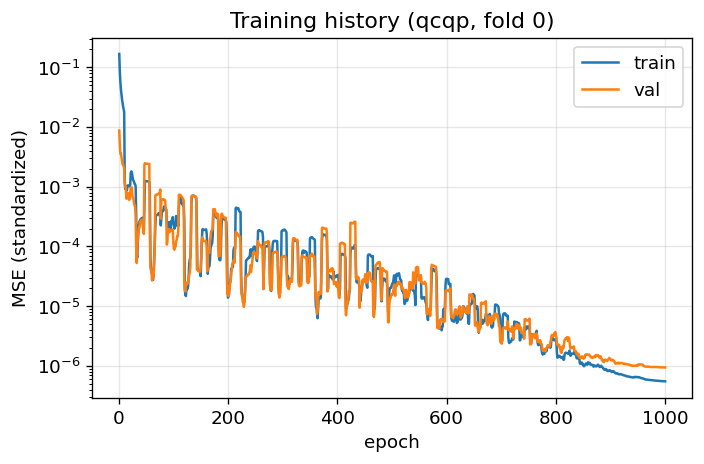

In [2]:
h = pd.read_csv(FIGS/'training_history_qcqp_fold0.csv')
fig, ax = plt.subplots(figsize=(6,4))
w = max(1, len(h)//100)
ax.plot(h.epoch, h.train_mse.rolling(w,min_periods=1).mean(), label='train')
ax.plot(h.epoch, h.val_mse.rolling(w,min_periods=1).mean(), label='val')
ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel('MSE (standardized)')
ax.set_title('Training history (qcqp, fold 0)'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'fig_training_history.pdf'); plt.show()

## 2. Normalized prediction-error box-and-whisker
Absolute NN error |g − v_r| normalized by std(v_r) over the test set, so every
experiment sits on a comparable scale. Pools all four folds.

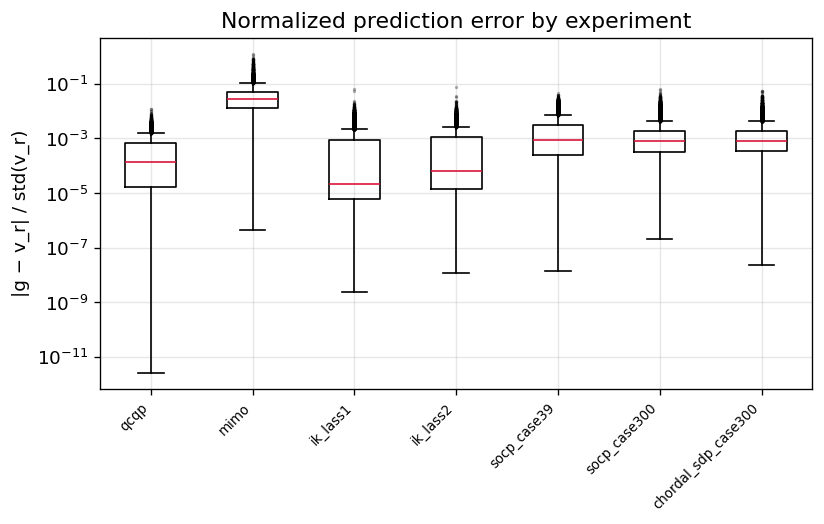

In [3]:
def small_pred(key):
    return pd.read_csv(RESULTS/key/'fold_test_predictions.csv')
def acopf_pred(cfg):
    return pd.read_csv(RESULTS/'acopf-cert'/cfg/'fold_test_predictions.csv')

# choose which configs to show (edit freely)
configs = [('qcqp',small_pred('qcqp')),('mimo',small_pred('mimo')),
           ('ik_lass1',small_pred('ik_lass1')),('ik_lass2',small_pred('ik_lass2'))]
for cfg in ['acopf_socp_case39','acopf_socp_case300','acopf_chordal_sdp_case300']:
    p = RESULTS/'acopf-cert'/cfg/'fold_test_predictions.csv'
    if p.exists(): configs.append((cfg.replace('acopf_',''), pd.read_csv(p)))

data, labels = [], []
for name, d in configs:
    err = np.abs(d['g']-d['v']).values
    s = d['v'].std() or 1.0
    data.append(err/s); labels.append(name)
fig, ax = plt.subplots(figsize=(max(7,0.8*len(labels)),4.5))
ax.boxplot(data, tick_labels=labels, showfliers=True,
           flierprops=dict(marker='.',markersize=2,alpha=0.3),
           medianprops=dict(color='crimson'))
ax.set_yscale('log'); ax.set_ylabel('|g − v_r| / std(v_r)')
ax.set_title('Normalized prediction error by experiment')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
fig.tight_layout(); fig.savefig(FIGS/'fig_error_boxplot.pdf'); plt.show()

## 3. ROC curves
One curve per classifier from `results/roc_curves/<config>.npz`, colored by
experiment. AUC in the legend.

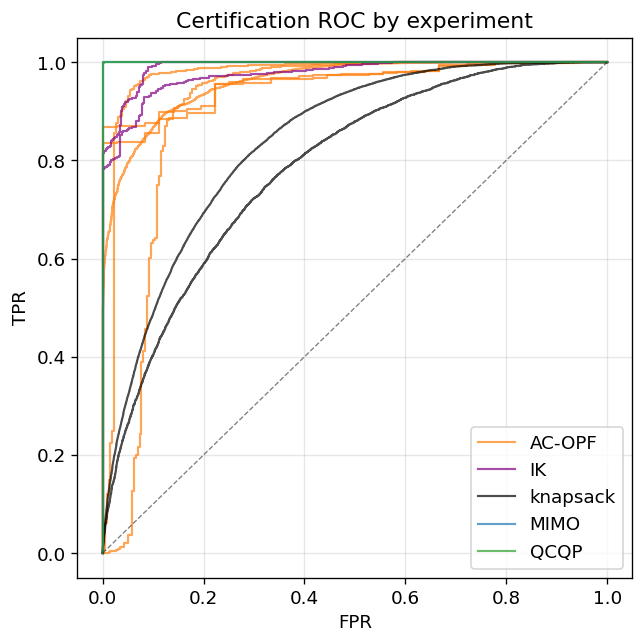

,config,auc,n_pos,n_neg
0,qcqp,0.999974,10036,9964
1,mimo,1.000000,19984,16
2,ik_lass1,0.975088,19100,872
3,ik_lass2,0.989888,19100,872
4,acopf_socp_case9,NaN,20000,0
5,acopf_socp_case14,NaN,20000,0
6,acopf_socp_case39,0.955866,18568,36
7,acopf_socp_case89pegase,NaN,19092,0
8,acopf_socp_case118,NaN,20000,0
9,acopf_socp_case300,0.899299,15508,260


In [4]:
def exp_of(cfg):
    if cfg.startswith('acopf'): return 'AC-OPF'
    if cfg.startswith('ik'): return 'IK'
    if cfg=='mimo': return 'MIMO'
    if cfg=='qcqp': return 'QCQP'
    if 'knapsack' in cfg: return 'knapsack'
    return 'other'

fig, ax = plt.subplots(figsize=(5.5,5.5))
seen=set()
for f in sorted((RESULTS/'roc_curves').glob('*.npz')):
    z = np.load(f, allow_pickle=True); cfg=f.stem; e=exp_of(cfg)
    lbl = e if e not in seen else None; seen.add(e)
    ax.plot(z['fpr'], z['tpr'], color=EXP_COLOR.get(e,'gray'), alpha=0.7, lw=1.3, label=lbl)
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Certification ROC by experiment')
ax.legend(); fig.tight_layout(); fig.savefig(FIGS/'fig_roc_curves.pdf'); plt.show()

# AUC table for reference
pd.read_csv(RESULTS/'roc_auc_summary.csv')[['config','auc','n_pos','n_neg']]